# Лабораторная работа 2

## Задание

Требуется сделать имплементацию с нуля используя только NumPy:
- Конвертация между цветовыми пространствами
    * RGB -> HSV
    * RGB -> HSL
- Blending изображений (с параметрами 𝜶, 𝜷, и 𝜸)
- Пороговая обработка
    * Бинарная
    * Обратная бинарная
    * Зануляющая (To zero)
    * Обратная зануляющая
    * Truncated
    * Гауссовская адаптивная
- Размытие и сглаживание
    * Применение собственного фильтра
    * Медианное размытие
    * Гауссовская (с генерацией гауссовского фильтра!)
- Применение фильтра Собеля
- Эквализация гистограммы для чёрно-белых фотографий
    * Расчёт частоты каждого пиксельного значения (построение гистограммы)
    * Использование кумулятивной функции распределения для эквализации

Для визуализации разрешено использовать Matplotlib.
В качестве результата требуется взять несколько изображений из Интернета (или самим сфотографировать) и показать работу самописных алгоритмов. Также сравнить бок о бок с работой OpenCV.


---

In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Task 1. Конвертация между цветовыми пространствами

Прежде всего, значения RGB ($0-255$) нужно привести к диапазону $[0, 1]$:

$$R' = R/255, \quad G' = G/255, \quad B' = B/255$$

Затем для каждого пикселя находим:

$$C_{max} = \max(R', G', B')$$
$$C_{min} = \min(R', G', B')$$
$$\Delta = C_{max} - C_{min} (Хрома)$$

**Расчет Hue (Тон)** — одинаков для HSV и HSL<br>Тон определяет цвет и рассчитывается в градусах от $0^\circ$ до $360^\circ$ на основе того, какой канал был максимальным ($C_{max}$):

- Если $\Delta = 0$, то $H = 0^\circ$ (это оттенок серого).

- Если $C_{max} = R'$, то $H = 60^\circ \times \left( \frac{G' - B'}{\Delta} \mod 6 \right)$

- Если $C_{max} = G'$, то $H = 60^\circ \times \left( \frac{B' - R'}{\Delta} + 2 \right)$

- Если $C_{max} = B'$, то $H = 60^\circ \times \left( \frac{R' - G'}{\Delta} + 4 \right)$

Формулы для HSV:

**Value (Значение/Яркость)** <br>Яркость в HSV — это просто максимальное значение из трех каналов:$$V = C_{max}$$

**Saturation (Насыщенность)** <br>Если $C_{max}$ равен нулю, то насыщенность $0$. В остальном:$$S = \begin{cases} 0, & C_{max} = 0 \\ \frac{\Delta}{C_{max}}, & C_{max} \neq 0 \end{cases}$$

Формулы для HSL:

**Lightness (Светлота)** <br>В отличие от HSV, здесь берется среднее между самым ярким и самым тусклым подканалом:$$L = \frac{C_{max} + C_{min}}{2}$$

**Saturation (Насыщенность)**<br>Здесь логика сложнее, так как она зависит от того, насколько близко значение $L$ к белому или черному цвету:$$S = \begin{cases} 0, & \Delta = 0 \\ \frac{\Delta}{1 - |2L - 1|}, & \Delta \neq 0 \end{cases}$$

#### Конвертация RGB -> HSV

In [11]:
def rgb_to_hsv(img):
    # Нормализация
    img = img.astype(np.float32) / 255.0
    r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]
    
    max_c = np.max(img, axis=2)
    min_c = np.min(img, axis=2)
    delta = max_c - min_c

    # Расчет Hue
    h = np.zeros_like(max_c)

    # Маски для разных цветовых секторов
    mask_r = (max_c == r) & (delta != 0)
    mask_g = (max_c == g) & (delta != 0)
    mask_b = (max_c == b) & (delta != 0)
    
    h[mask_r] = 60 * (((g[mask_r] - b[mask_r]) / delta[mask_r]) % 6)
    h[mask_g] = 60 * (((b[mask_g] - r[mask_g]) / delta[mask_g]) + 2)
    h[mask_b] = 60 * (((r[mask_b] - g[mask_b]) / delta[mask_b]) + 4)
    
    # Расчет Value
    v = max_c
    
    # Расчет Saturation
    s = np.zeros_like(max_c)
    s[max_c != 0] = delta[max_c != 0] / max_c[max_c != 0]
    
    # Приводим к формату OpenCV для дальнейшего его сравнения (H: 0-180, S: 0-255, V: 0-255)
    h_cv = (h / 2).astype(np.uint8)
    s_cv = (s * 255).astype(np.uint8)
    v_cv = (v * 255).astype(np.uint8)
    
    return np.stack([h_cv, s_cv, v_cv], axis=2)

#### Конвертация RGB -> HSL

In [12]:
def rgb_to_hsl(img):
    img = img.astype(np.float32) / 255.0
    r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]
    
    max_c = np.max(img, axis=2)
    min_c = np.min(img, axis=2)
    delta = max_c - min_c

    h = np.zeros_like(max_c)
    mask_r = (max_c == r) & (delta != 0)
    mask_g = (max_c == g) & (delta != 0)
    mask_b = (max_c == b) & (delta != 0)
    
    h[mask_r] = 60 * (((g[mask_r] - b[mask_r]) / delta[mask_r]) % 6)
    h[mask_g] = 60 * (((b[mask_g] - r[mask_g]) / delta[mask_g]) + 2)
    h[mask_b] = 60 * (((r[mask_b] - g[mask_b]) / delta[mask_b]) + 4)
    
    l = (max_c + min_c) / 2
    
    s = np.zeros_like(max_c)
    denom = 1 - np.abs(1 - 2 * l)
    mask_s = (delta != 0)
    s[mask_s] = delta[mask_s] / denom[mask_s]
    
    h_cv = (h / 2).astype(np.uint8)
    s_cv = (s * 255).astype(np.uint8)
    l_cv = (l * 255).astype(np.uint8)
    
    return np.stack([h_cv, l_cv, s_cv], axis=2)

Сравнение результата имплеметированных методов и методов OpenCV

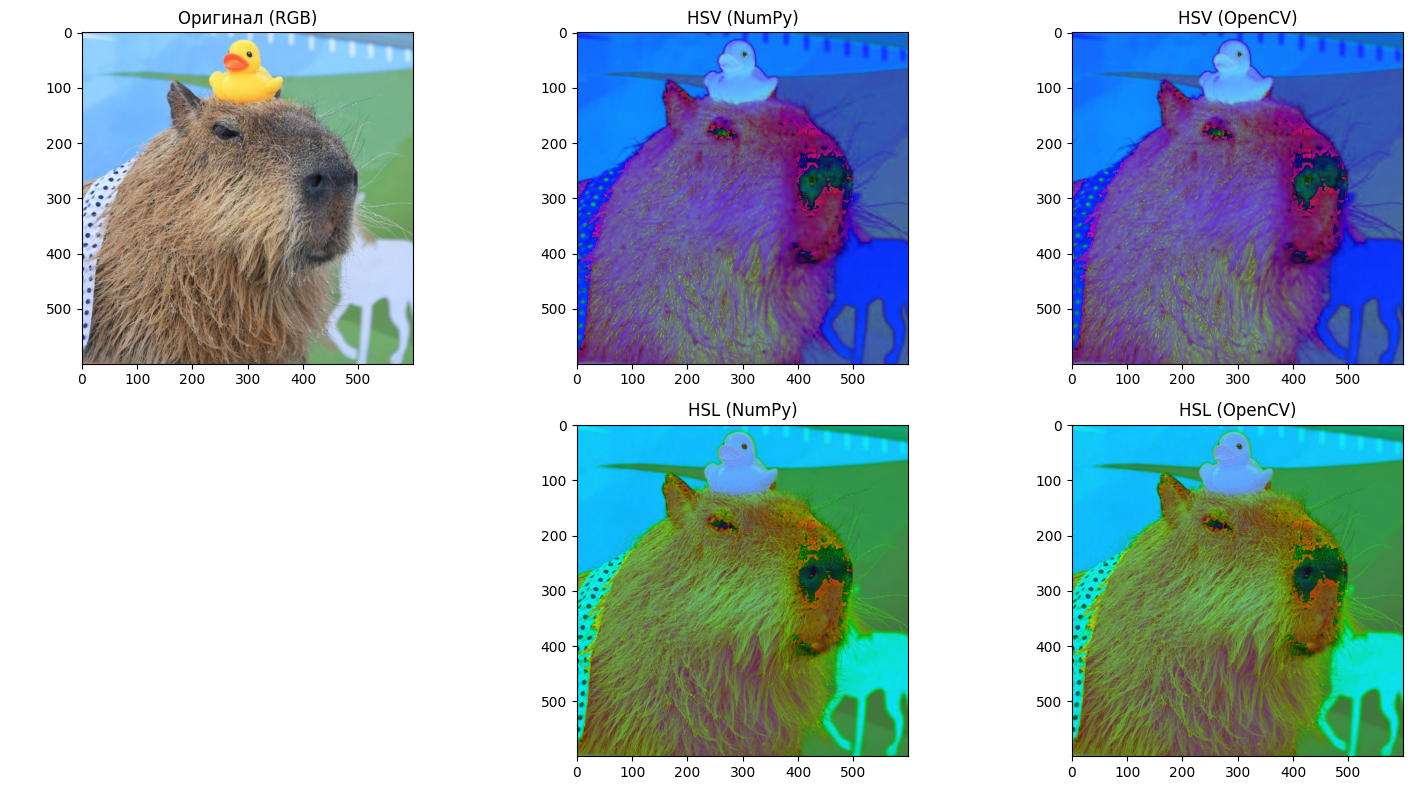

In [13]:
img = cv2.imread('./src/img1.jpg')

hsv_np = rgb_to_hsv(img)
hsl_np = rgb_to_hsl(img)

hsv_cv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
hsl_cv = cv2.cvtColor(img, cv2.COLOR_RGB2HLS)

fig, axs = plt.subplots(2, 3, figsize=(15, 8))

axs[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axs[0, 0].set_title("Оригинал (RGB)")

axs[0, 1].imshow(hsv_np)
axs[0, 1].set_title("HSV (NumPy)")

axs[0, 2].imshow(hsv_cv)
axs[0, 2].set_title("HSV (OpenCV)")

axs[1, 0].axis('off')

axs[1, 1].imshow(hsl_np)
axs[1, 1].set_title("HSL (NumPy)")

axs[1, 2].imshow(hsl_cv)
axs[1, 2].set_title("HSL (OpenCV)")

plt.tight_layout()
plt.show()

## Task 2. Blending изображений (с параметрами 𝜶, 𝜷, и 𝜸)

Формула:$$Result(x,y) = \alpha \cdot Img_1(x,y) + \beta \cdot Img_2(x,y) + \gamma$$Параметры:
- $\alpha$: вес (прозрачность) первого изображения.
- $\beta$: вес второго изображения.
- $\gamma$: скаляр, добавляемый к каждой сумме (яркость).

In [14]:
def blending_numpy(img1, img2, alpha, beta, gamma):
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)
    
    blended = alpha * img1 + beta * img2 + gamma
    
    return np.clip(blended, 0, 255).astype(np.uint8)

Сравнение имплементации метода и метода из OpenCV

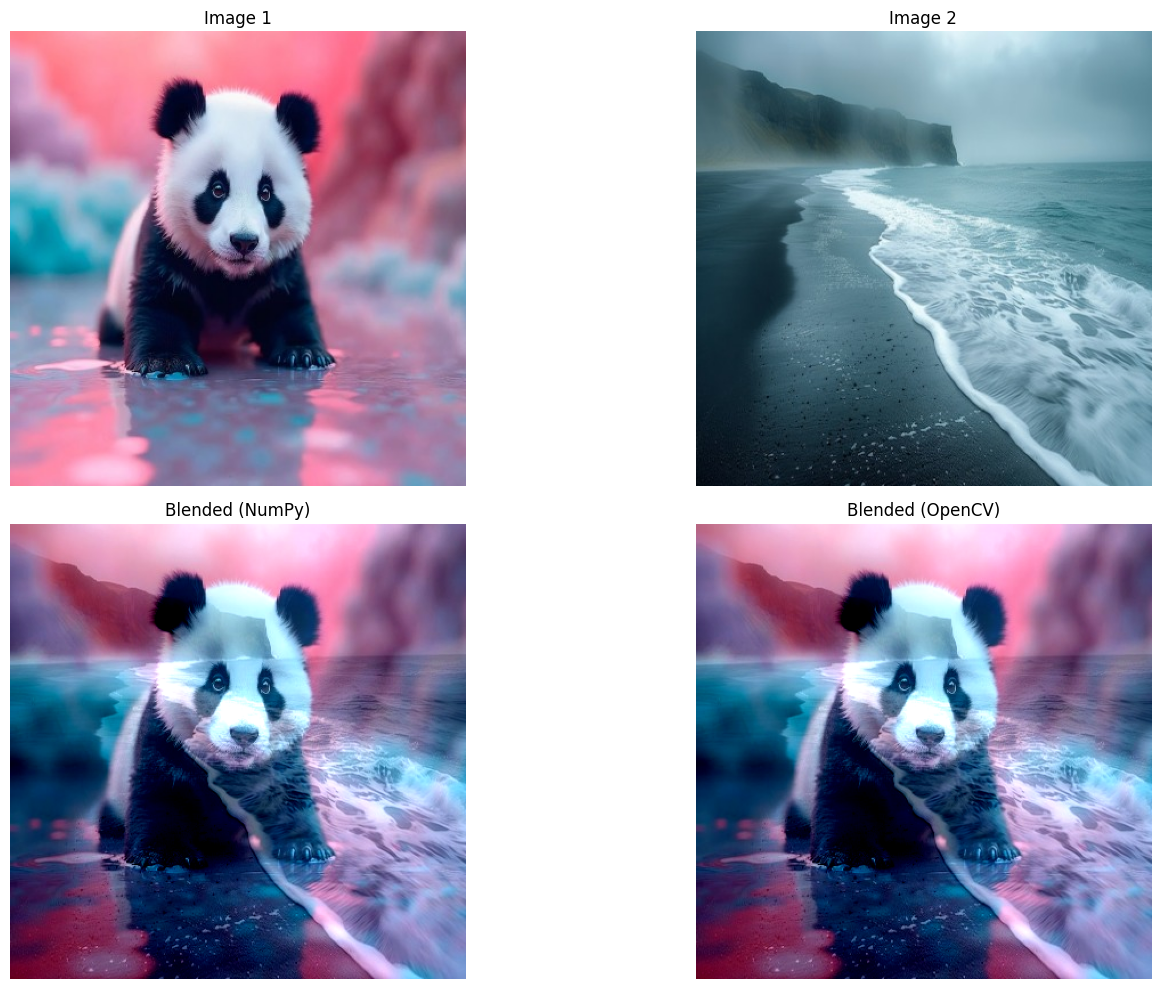

In [15]:
src1 =cv2.cvtColor(cv2.imread('./src/img2.jpg'), cv2.COLOR_BGR2RGB)
src2 = cv2.cvtColor(cv2.imread('./src/img3.jpg'), cv2.COLOR_BGR2RGB)
alpha = 1
beta = 1
gamma = -150

dst_cv = cv2.addWeighted(src1, alpha, src2, beta, gamma)
dst_np = blending_numpy(src1, src2, alpha, beta, gamma)

plt.figure(figsize=(16, 10))

titles = ['Image 1', 'Image 2', 
          'Blended (NumPy)', 'Blended (OpenCV)']
images = [src1, src2, dst_np, dst_cv]

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Task 3. Пороговая обработка.

Во всех формулах ниже $src(x,y)$ — это входной пиксель, $thresh$ — порог, $maxVal$ — значение, которое присваивается при выполнении условия (обычно 255).

**Бинарная (Binary)**
<br>Всё, что ярче порога — белое, остальное — чёрное.$$dst(x,y) = \begin{cases} maxVal, & \text{if } src(x,y) > thresh \\ 0, & \text{otherwise} \end{cases}$$

**Обратная бинарная (Binary Inverted)**
<br>Всё, что ярче порога — чёрное.$$dst(x,y) = \begin{cases} 0, & \text{if } src(x,y) > thresh \\ maxVal, & \text{otherwise} \end{cases}$$

**Усечение (Truncated)**
<br>Пиксели, которые ярче порога, «прижимаются» к значению порога. Остальные не меняются.$$dst(x,y) = \begin{cases} thresh, & \text{if } src(x,y) > thresh \\ src(x,y), & \text{otherwise} \end{cases}$$

**Зануляющая (To Zero)**
<br>Всё, что темнее порога, становится абсолютно чёрным. Яркие пиксели не меняются.$$dst(x,y) = \begin{cases} src(x,y), & \text{if } src(x,y) > thresh \\ 0, & \text{otherwise} \end{cases}$$

**Обратная зануляющая (To Zero Inverted)** 
<br> Всё, что ярче порога, становится чёрным.$$dst(x,y) = \begin{cases} 0, & \text{if } src(x,y) > thresh \\ src(x,y), & \text{otherwise} \end{cases}$$

**Гауссовская адаптивная пороговая обработка** 
<br>В отличие от простых методов, здесь порог $T(x,y)$ рассчитывается индивидуально для каждого пикселя.

Алгоритм:

- Берется окрестность пикселя размером $k \times k$ (например, $11 \times 11$).
- Вычисляется средневзвешенное значение яркости в этой окрестности, где веса — это коэффициенты Гаусса (центральные пиксели важнее периферийных).
- Из полученного значения вычитается константа $C$ (для тонкой настройки).
- Итоговое значение и есть локальный порог $T(x,y)$.
- Применяется обычная бинарная логика: если $src(x,y) > T(x,y)$, то 255, иначе 0.

Формула порога:$$T(x,y) = (src * G_k)(x,y) - C$$Где $*$ — операция свертки, а $G_k$ — ядро Гаусса.

In [16]:
def get_gaussian_kernel(size, sigma):
    """Создает матрицу Гаусса заданного размера."""
    k = (size - 1) / 2
    x, y = np.mgrid[-k:k+1, -k:k+1]
    g = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return g / g.sum()

def convolve2d(image, kernel):
    """Применяет фильтр (свертку) к изображению."""
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape
    
    pad_h, pad_w = k_h // 2, k_w // 2
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    output = np.zeros_like(image, dtype=np.float32)
    
    for i in range(img_h):
        for j in range(img_w):
            region = padded_img[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(region * kernel)
            
    return output

def adaptive_threshold_gauss(image, max_val=255, block_size=11, C=2):
    """
    Адаптивный порог:
    T(x,y) = WeightedMean(x,y) - C
    """

    if len(image.shape) == 3:
        image = np.mean(image, axis=2).astype(np.uint8)
    
    kernel = get_gaussian_kernel(block_size, sigma=block_size/6)
    local_mean = convolve2d(image.astype(np.float32), kernel)
    thresholds = local_mean - C

    result = np.zeros_like(image)
    result[image > thresholds] = max_val
    
    return result

In [17]:
def threshold(img, thresh, max_val, type='binary'):
    res = np.zeros_like(img)
    if type == 'binary':
        res[img > thresh] = max_val
    elif type == 'binary_inv':
        res[img <= thresh] = max_val
    elif type == 'trunc':
        res = img.copy()
        res[img > thresh] = thresh
    elif type == 'tozero':
        res[img > thresh] = img[img > thresh]
    elif type == 'tozero_inv':
        res[img <= thresh] = img[img <= thresh]
    elif type == 'gauss':
        res = adaptive_threshold_gauss(img, max_val=max_val, block_size=11, C=2)
    return res

Сравнение результата и OpenCV

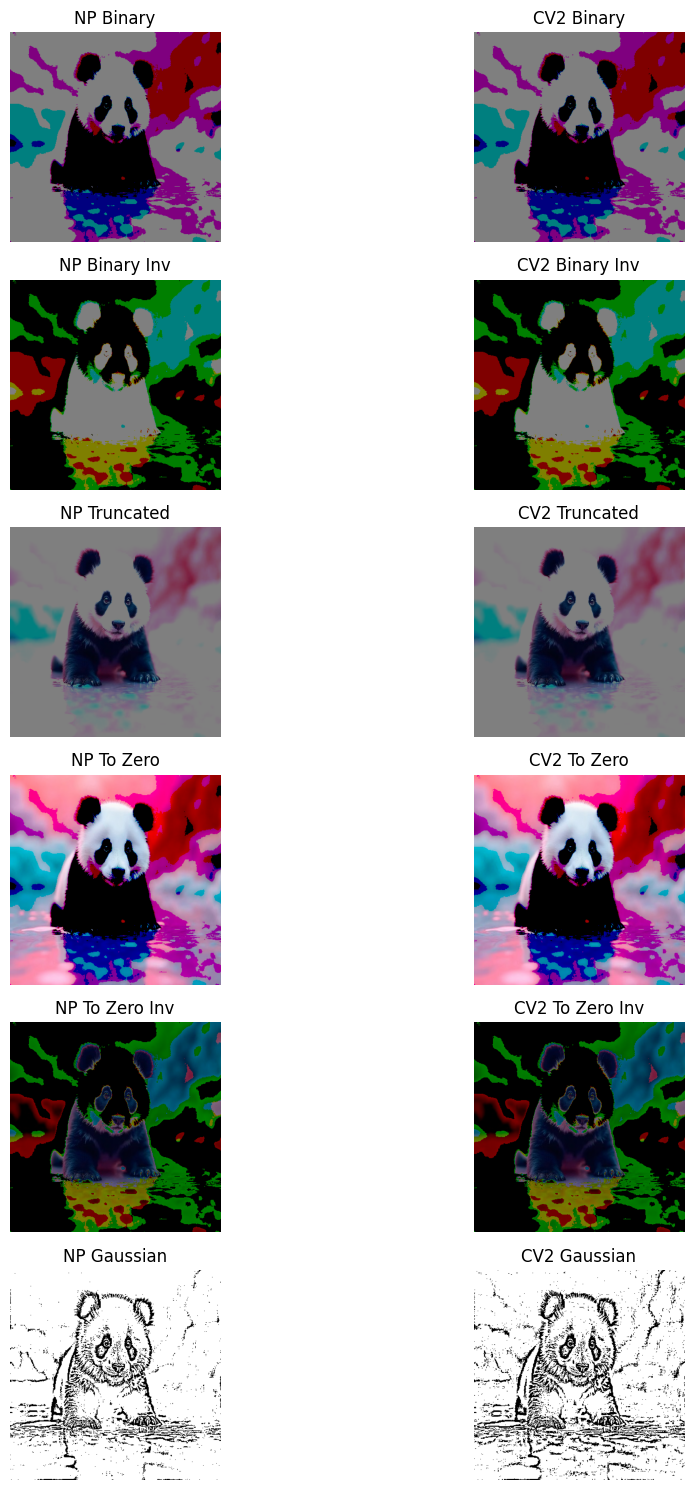

In [ ]:
img = cv2.cvtColor(cv2.imread('./src/img2.jpg'), cv2.COLOR_BGR2RGB)

T = 127
M = 127

bin_thresh = threshold(img, T, M, 'binary').astype(np.uint8)
bin_inv_thresh = threshold(img, T, M, 'binary_inv').astype(np.uint8)
trunc_thresh = threshold(img, T, M, 'trunc').astype(np.uint8)
tozero_thresh = threshold(img, T, M, 'tozero').astype(np.uint8)
tozero_inv_thresh = threshold(img, T, M, 'tozero_inv').astype(np.uint8)
gauss_tresh = threshold(img, T, M, 'gauss').astype(np.uint8)
    
results_np = {
        "Binary": bin_thresh,
        "Binary Inv": bin_inv_thresh,
        "Truncated": trunc_thresh,
        "To Zero": tozero_thresh,
        "To Zero Inv": tozero_inv_thresh,
        "Gaussian": gauss_tresh}

results_cv = {
    "Binary": cv2.threshold(img, T, M, cv2.THRESH_BINARY)[1],
    "Binary Inv": cv2.threshold(img, T, M, cv2.THRESH_BINARY_INV)[1],
    "Truncated": cv2.threshold(img, T, M, cv2.THRESH_TRUNC)[1],
    "To Zero": cv2.threshold(img, T, M, cv2.THRESH_TOZERO)[1],
    "To Zero Inv": cv2.threshold(img, T, M, cv2.THRESH_TOZERO_INV)[1],
    "Gaussian": cv2.adaptiveThreshold(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), M, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, blockSize=11, C=2)
}


keys = list(results_np.keys())
fig, axes = plt.subplots(len(keys), 2, figsize=(12, 15))

for i, key in enumerate(keys):

    axes[i, 0].imshow(results_np[key], cmap='gray')
    axes[i, 0].set_title(f"NP {key}")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(results_cv[key], cmap='gray')
    axes[i, 1].set_title(f"CV2 {key}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## Task 4. Размытие и сглаживание

#### **Применение собственного фильтра**
Ядро размером $m \times n$ (обычно нечетным, например, $3 \times 3$) накладывается на каждый пиксель изображения так, чтобы центр ядра совпадал с текущим пикселем.

Затем значения пикселей изображения, оказавшихся под ядром, перемножаются с соответствующими коэффициентами ядра.

 Сумма этих произведений становится новым значением центрального пикселя.$$g(x, y) = \sum_{i=-a}^{a} \sum_{j=-b}^{b} w(i, j) \cdot f(x-i, y-j)$$Где $w$ — ядро, $f$ — исходное изображение, $g$ — результат.

#### **Медианное размытие**
Вместо вычисления среднего или взвешенного значения, он выбирает одно из существующих значений в окрестности:

Выбирается окно (апертура) размером $k \times k$.

Для каждого пикселя все значения в пределах окна собираются в один список.

Список сортируется по возрастанию.

Центральному пикселю присваивается медиана — значение, находящееся ровно посередине отсортированного списка.

#### **Гауссовское размытие**
Этот метод использует в качестве ядра значения, рассчитанные по функции нормального распределения Гаусса.

Значения в ядре рассчитываются по формуле двумерного Гаусса:$$G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$$Где $x, y$ — расстояние от центра ядра до текущей ячейки (например, для ядра $3 \times 3$ координаты меняются от $-1$ до $1$). $\sigma$ — отклонение.

Расчет: Для каждой ячейки ядра вычисляется значение $G(x, y)$.

Нормализация: чтобы общая яркость изображения не изменилась, сумма всех элементов ядра должна быть равна 1. Все вычисленные значения делятся на их общую сумму:$$w_{normalized} = \frac{w_i}{\sum w_j}$$

In [25]:
def apply_custom_filter(image, kernel):
    if len(image.shape) == 3:
        return np.stack([apply_custom_filter(image[:,:,i], kernel) for i in range(3)], axis=2)
    
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2
    
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    output = np.zeros_like(image, dtype=np.float32)
    
    for i in range(img_h):
        for j in range(img_w):
            region = padded[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(region * kernel)
            
    return np.clip(output, 0, 255).astype(np.uint8)

def gaussian_blur(size, sigma):
    ax = np.linspace(-(size - 1) / 2., (size - 1) / 2., size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / np.sum(kernel)

def median_blur(image, size):
    if len(image.shape) == 3:
        return np.stack([median_blur(image[:,:,i], size) for i in range(3)], axis=2)
    
    img_h, img_w = image.shape
    pad = size // 2
    padded = np.pad(image, ((pad, pad), (pad, pad)), mode='reflect')
    output = np.zeros_like(image)
    
    for i in range(img_h):
        for j in range(img_w):
            region = padded[i:i+size, j:j+size]
            output[i, j] = np.median(region)
            
    return output

Сравнение методов

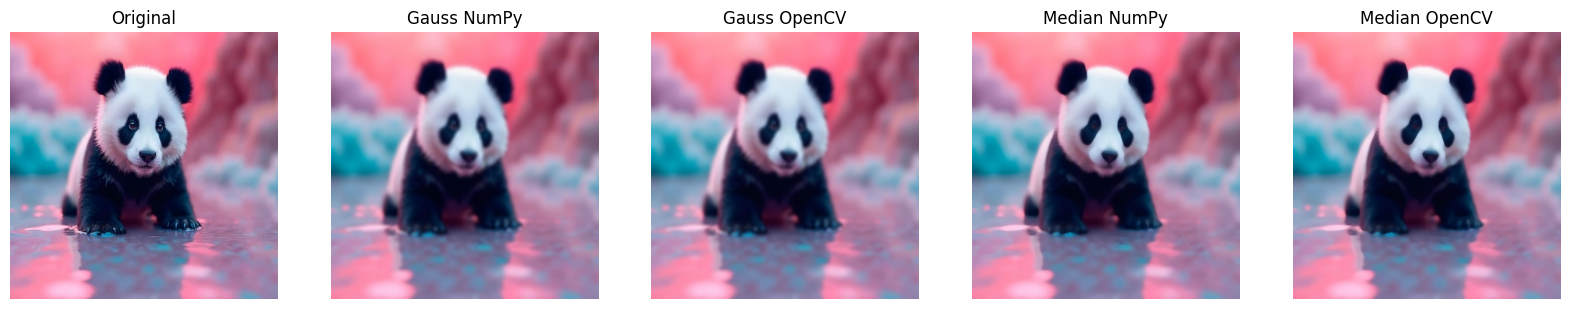

In [26]:
img = cv2.cvtColor(cv2.imread('./src/img2.jpg'), cv2.COLOR_BGR2RGB)

k_size = 7
sigma = 3

g_kernel = gaussian_blur(k_size, sigma)
res_gauss_np = apply_custom_filter(img, g_kernel)
res_median_np = median_blur(img, k_size)

res_gauss_cv = cv2.GaussianBlur(img, (k_size, k_size), sigma)
res_median_cv = cv2.medianBlur(img, k_size)

titles = ['Original', 'Gauss NumPy', 'Gauss OpenCV', 'Median NumPy', 'Median OpenCV']
images = [img, res_gauss_np, res_gauss_cv, res_median_np, res_median_cv]

plt.figure(figsize=(20, 10))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')
plt.show()

## Task 5. Применение фильтра Собеля

Фильтр ищет места, где цвет резко меняется (например, с черного на белый), и помечает их как контуры.

#### **Операция свертки (Ядра Собеля)**
Алгоритм использует две матрицы (ядра) размером $3 \times 3$. Одно ядро ищет изменения яркости по горизонтали, другое — по вертикали.Горизонтальное ядро ($G_x$):

$$\begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}$$
Оно подчеркивает вертикальные линии. Левая колонка отрицательная, правая — положительная. Если пиксели слева и справа одинаковы, результат будет близок к нулю. Если разные — получится большое число.

Вертикальное ядро ($G_y$):$$\begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$
Оно подчеркивает горизонтальные линии, сравнивая верхнюю и нижнюю части окна.

#### **Пошаговый алгоритм**

**Подготовка:**

Фильтр Собеля обычно применяется к одноканальному (чб) изображению, так как интересует именно изменение интенсивности света, а не сам цвет.
 
**Применение свертки:** 
 
Скользим каждым ядром по изображению. Для каждого пикселя берем его окрестность $3 \times 3$, перемножаем соответствующие элементы с ядром и суммируем результат. Результат работы с $G_x$ и $G_y$ дает матрицу горизонтального градиента и вертикального градиента соответсвенно.
 
**Расчет общей интенсивности границы:** 
 
Чтобы получить итоговую карту контуров, объединяем два градиента по формуле, похожей на теорему Пифагора:$$G = \sqrt{G_x^2 + G_y^2}$$
Это дает величину (амплитуду) изменения яркости в каждой точке.
 
**Нормализация:**
 
Так как значения после возведения в квадрат и сложения могут выйти за пределы 255, итоговый результат обрезается или масштабируется до стандартного диапазона $0–255$.

In [27]:
def sobel_filter_numpy(image):
    if len(image.shape) == 3:
        image = np.mean(image, axis=2)
    
    image = image.astype(np.float64)
    
    # Ядра Собеля
    Kx = np.array([[-1, 0, 1], 
                   [-2, 0, 2], 
                   [-1, 0, 1]], dtype=np.float64)
    
    Ky = np.array([[-1, -2, -1], 
                   [ 0,  0,  0], 
                   [ 1,  2,  1]], dtype=np.float64)
    
    Gx = convolve2d(image, Kx)
    Gy = convolve2d(image, Ky)
    
    G = np.sqrt(Gx**2 + Gy**2)
    
    G = (G / G.max() * 255).astype(np.uint8)
    
    return G, Gx, Gy

Сравнение методов

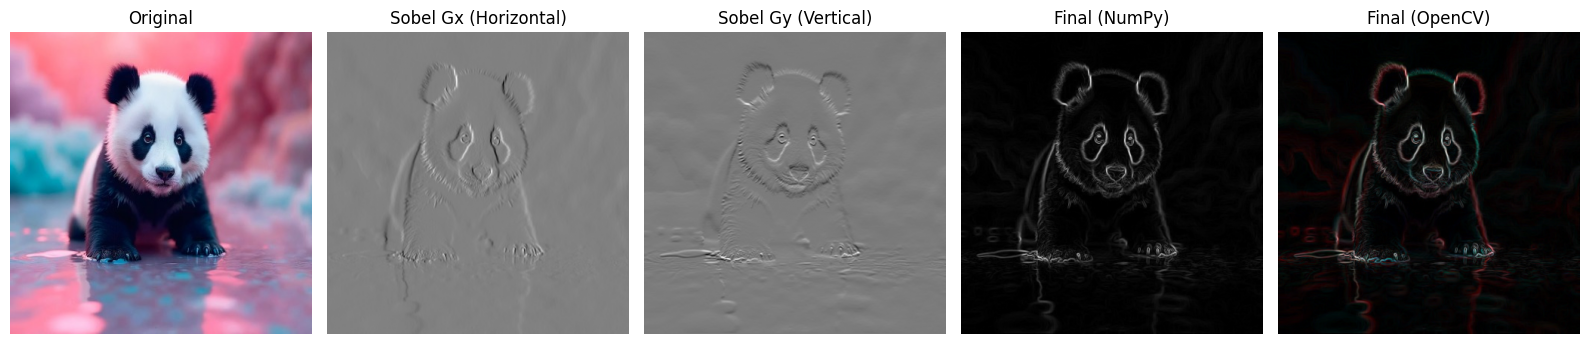

In [ ]:
img = cv2.cvtColor(cv2.imread('./src/img2.jpg'), cv2.COLOR_BGR2RGB)

sobel_np, gx_np, gy_np = sobel_filter_numpy(img)

cv_gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
cv_gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_cv = cv2.magnitude(cv_gx, cv_gy)
sobel_cv = (sobel_cv / sobel_cv.max() * 255).astype(np.uint8)

plt.figure(figsize=(16, 8))

titles = ['Original', 'Sobel Gx (Horizontal)', 'Sobel Gy (Vertical)', 'Final (NumPy)', 'Final (OpenCV)']
images = [img, gx_np, gy_np, sobel_np, sobel_cv]

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Task 6. Эквализация гистограммы для чёрно-белых фотографий

#### **Гистограмма**
Гистограмма изображения - дискретная функция, которая отображает количество пикселей для каждого уровня яркости.

$L$ - общее количество возможных уровней серого (обычно 256 для 8-битных изображений, от 0 до 255).

$n_k$ - количество пикселей, имеющих уровень яркости $r_k$.

$N$ - общее количество пикселей в изображении ($N = \text{ширина} \times \text{высота}$).

Чтобы работать с вероятностями, рассчитывается нормализованная гистограмма, которая в статистике соответствует функции плотности вероятности:$$p_r(r_k) = \frac{n_k}{N}, \quad k = 0, 1, \dots, L-1$$Сумма всех значений $p_r(r_k)$ всегда равна 1.

#### **Кумулятивная функция**
Она показывает вероятность того, что случайно выбранный пиксель имеет яркость, не превышающую заданный уровень.

Формула расчета:$$cdf(r_k) = \sum_{i=0}^{k} p_r(r_i)$$

Каждое значение $cdf(r_k)$ является суммой вероятностей всех уровней яркости от $0$ до $k$.

- $cdf(0)$ — вероятность самого темного уровня
- $cdf(L-1)$ — всегда равна 1.0

#### **Эквализация**
Новое значение яркости пикселя $s_k$ вычисляется на основе старого значения $r_k$ по формуле:$$s_k = T(r_k) = \text{round}\left( (L - 1) \cdot cdf(r_k) \right)$$

Пошаговый алгоритм:
- Сбор статистики - пройти по всем пикселям изображения и подсчитать частоту появления каждого значения от 0 до 255.
- Накопление - вычислить CDF, суммируя полученные частоты.
- Нормализация - умножить значения CDF на $(L-1)$ и округлить до ближайшего целого числа

In [29]:
def calculate_histogram(image):
    hist = np.zeros(256, dtype=int)
    pixels = image.flatten()
    
    for pixel in pixels:
        hist[pixel] += 1
    return hist

def calculate_cdf(hist):
    cdf = hist.cumsum()
    
    cdf_normalized = cdf / cdf[-1] 
    return cdf_normalized

def equalize_histogram_numpy(image):
    hist = calculate_histogram(image)
    cdf = calculate_cdf(hist)

    lut = np.round(cdf * 255).astype(np.uint8)
    img_equalized = lut[image]
    
    return img_equalized, hist, lut

Сравние методов

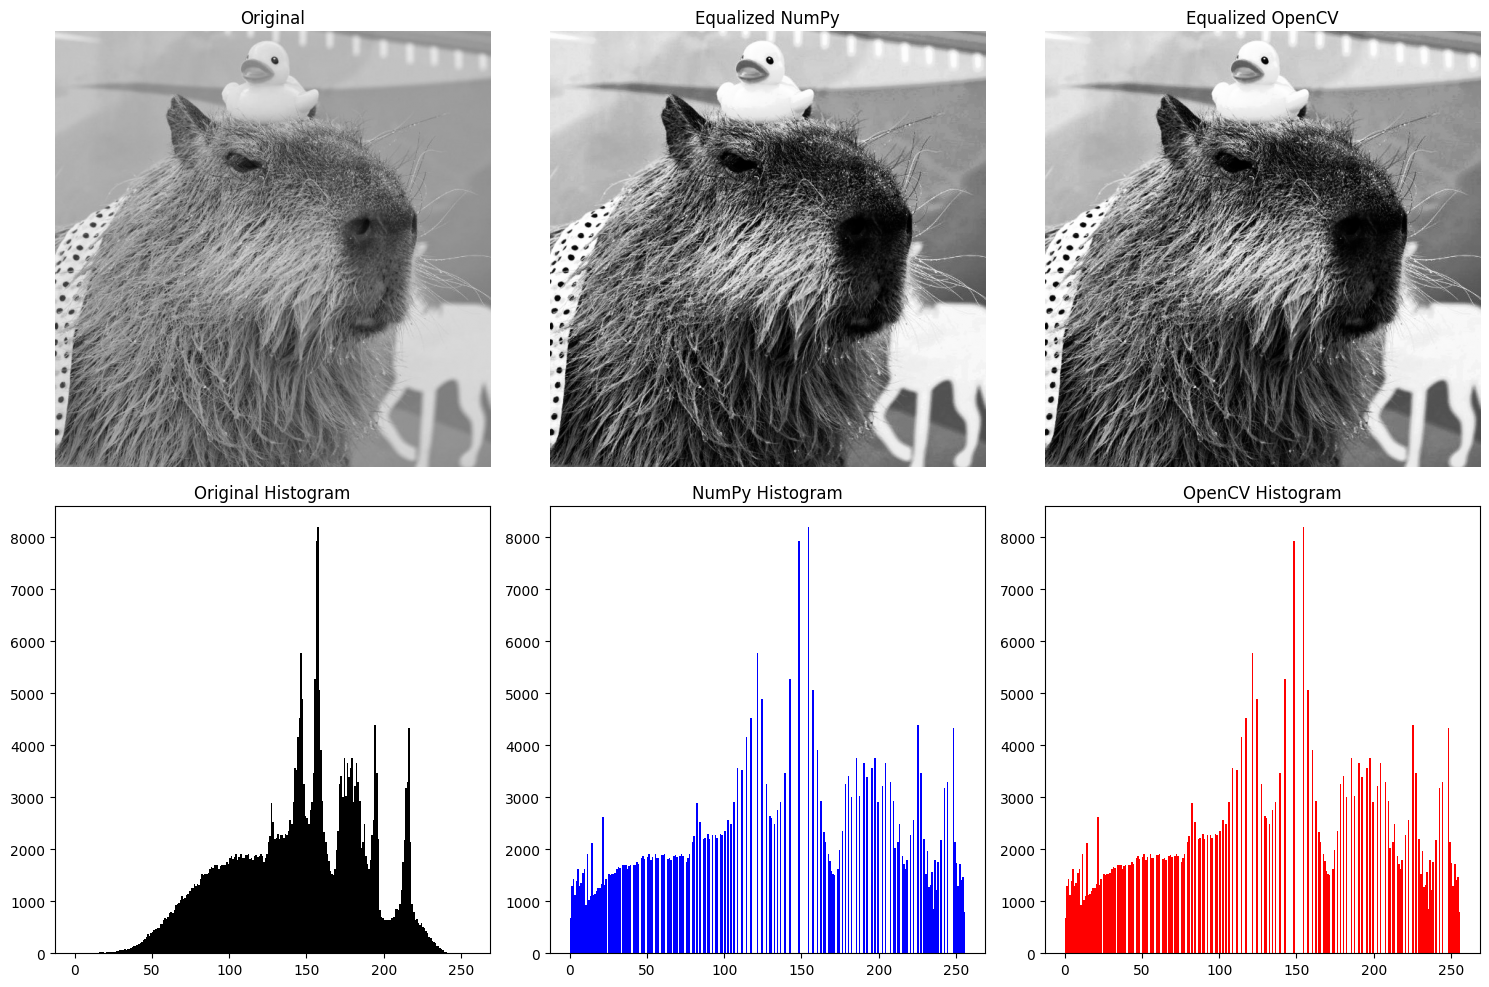

In [ ]:
img = cv2.cvtColor(cv2.imread('./src/img1.jpg'), cv2.COLOR_BGR2GRAY)

img_np, hist_np, _ = equalize_histogram_numpy(img)
img_cv = cv2.equalizeHist(img)


plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(img_np, cmap='gray')
plt.title("Equalized NumPy")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(img_cv, cmap='gray')
plt.title("Equalized OpenCV")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.hist(img.flatten(), bins=256, range=[0,256], color='black')
plt.title("Original Histogram")

plt.subplot(2, 3, 5)
plt.hist(img_np.flatten(), bins=256, range=[0,256], color='blue')
plt.title("NumPy Histogram")

plt.subplot(2, 3, 6)
plt.hist(img_cv.flatten(), bins=256, range=[0,256], color='red')
plt.title("OpenCV Histogram")

plt.tight_layout()
plt.show()